In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv

In [17]:
load_dotenv()

llm_model = ChatOpenRouter(model="openai/gpt-oss-120b:free")

In [18]:
class TopicState(TypedDict):
    user_query: str
    technical_explanation: str
    pros_cons: str
    research_summary: str
    final_result: str
    

In [26]:
def technical_explanation(state: TopicState):
    user_query = state['user_query']

    prompt = f'''
You're a professional researcher. Give a brief technical explanation of the below user query.
Query: {user_query}
'''
    
    technical_explanation = llm_model.invoke(prompt).content

    return {'technical_explanation': technical_explanation}

In [27]:
def analyze_pros_cons(state: TopicState) -> TopicState:
    user_query = state['user_query']

    prompt = f'''
You're a professional researcher. Analyze pros and cons for the below user query.
Query: {user_query}
'''
    
    pros_cons = llm_model.invoke(prompt).content

    return {'pros_cons': pros_cons}

In [28]:
def summarize(state: TopicState):
    user_query = state['user_query']

    prompt = f'''
You're a professional researcher. Give a brief research summary for the below user query.
Query: {user_query}
'''
    
    research_summary = llm_model.invoke(prompt).content

    return {"research_summary": research_summary}

In [ ]:
def generate_final(state: TopicState) -> TopicState:
    user_query = state['user_query']
    technical_explanation = state['technical_explanation']
    pros_cons = state['pros_cons']
    research_summary = state['research_summary']

    prompt = f'''
You're a professional researcher. You are provided with a user query, its technical explanation, its pros and cons and its research summary. You have to produce a final result/answer that can be presented to the user.
- User query: {user_query}
- Technical explanation: {technical_explanation}
- Pros & cons: {pros_cons}
- Research summary: {research_summary}
'''
    
    final_result = llm_model.invoke(prompt).content

    state['final_result'] = final_result
    
    return state

In [30]:
graph = StateGraph(TopicState)

graph.add_node('technical_explanation', technical_explanation)
graph.add_node('analyze_pros_cons', analyze_pros_cons)
graph.add_node('summarize', summarize)
graph.add_node('generate_final', generate_final)

graph.add_edge(START, 'technical_explanation')
graph.add_edge(START, 'analyze_pros_cons')
graph.add_edge(START, 'summarize')
graph.add_edge('technical_explanation', 'generate_final')
graph.add_edge('analyze_pros_cons', 'generate_final')
graph.add_edge('summarize', 'generate_final')
graph.add_edge('generate_final', END)

workflow = graph.compile()

In [31]:
input_state = {'user_query': 'Explain the impact of AI on healthcare'}
output_state = workflow.invoke(input_state)

print(output_state['final_result'])

content='**The impact of artificial intelligence (AI) on healthcare is now measurable, broad‑ranging, and still evolving.** Below is a concise, evidence‑based overview that pulls together the technical details, real‑world outcomes, and the key trade‑offs you’ll want to keep in mind when thinking about how AI is reshaping the industry.\n\n---\n\n## 1.  Where AI Is Making the Biggest Difference  \n\n| Domain | Typical AI methods | Concrete, data‑driven results (2020‑2024) | Main limitations |\n|--------|-------------------|------------------------------------------|------------------|\n| **Medical Imaging & Diagnostics** | CNNs, Vision‑Transformers, self‑supervised pre‑training | •\u202f≥\u202f95\u202f% AUC for diabetic retinopathy, lung nodules, breast cancer – often outperforming board‑certified radiologists.<br>•\u202f10–30\u202f% faster time‑to‑report through automated triage. | • Heterogeneous scanner settings and image protocols.<br>• Need for large, external validation sets and FD

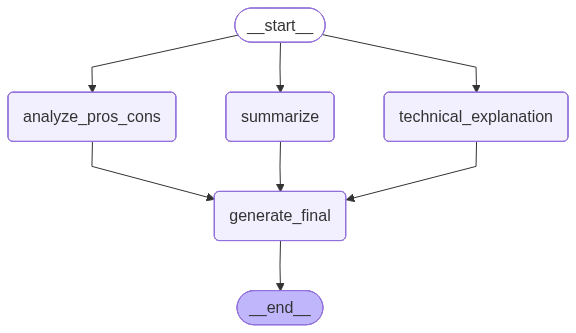

In [32]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())